# Linear Regression

Linear Regression models the relationship between one or more independent variables X and a dependent variable y by fitting a linear equation to observed data. The general form is:

$\hat{y} = m X + b$

Where:

w is the weight or slope

b is the bias or intercept

$\hat{y}$ is the predicted value

The parameters w and b are found by minimizing the Mean Squared Error (MSE):

MSE = $\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$



This is done either through a closed-form solution (Normal Equation) or iterative methods like gradient descent.



In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

To test our implementation in a clean and controlled environment, we use a synthetic dataset generated with make_regression() from sklearn.datasets.

This dataset has:

- A single input feature

- A continuous target variable

- Gaussian noise added to simulate real-world variation

The advantage of using synthetic data is that we know the underlying relationship is linear, allowing us to directly test how well the model recovers it.

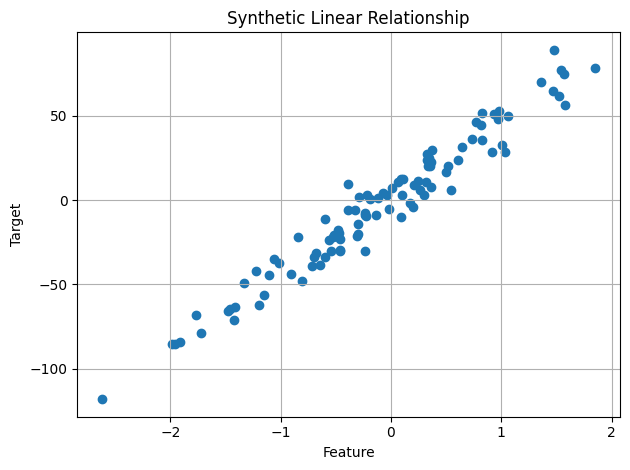

In [39]:
#Loading data
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Quick plot
plt.scatter(X, y)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Synthetic Linear Relationship")
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
#Building the Regressor object
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_epochs=1000):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.n_epochs):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            # Gradient descent update
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [41]:
#Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
#Implementing the regressor
my_lr = LinearRegression(learning_rate=0.01, n_epochs=1000)
my_lr.fit(X_train_scaled, y_train)
y_pred_custom = my_lr.predict(X_test_scaled)

# Evaluation
mse_custom = mean_squared_error(y_test, y_pred_custom)
r2_custom = r2_score(y_test, y_pred_custom)
print(f"Custom Linear Regression MSE: {mse_custom:.4f}")
print(f"Custom Linear Regression R^2: {r2_custom:.4f}")

Custom Linear Regression MSE: 104.2032
Custom Linear Regression R^2: 0.9374


In [43]:
#Comparing with scikit-learn regressor
sk_lr = LinearRegression()
sk_lr.fit(X_train_scaled, y_train)
y_pred_sklearn = sk_lr.predict(X_test_scaled)

#Evaluation
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)
print(f"Sklearn Linear Regression MSE: {mse_sklearn:.4f}")
print(f"Sklearn Linear Regression R^2: {r2_sklearn:.4f}")

Sklearn Linear Regression MSE: 104.2022
Sklearn Linear Regression R^2: 0.9374


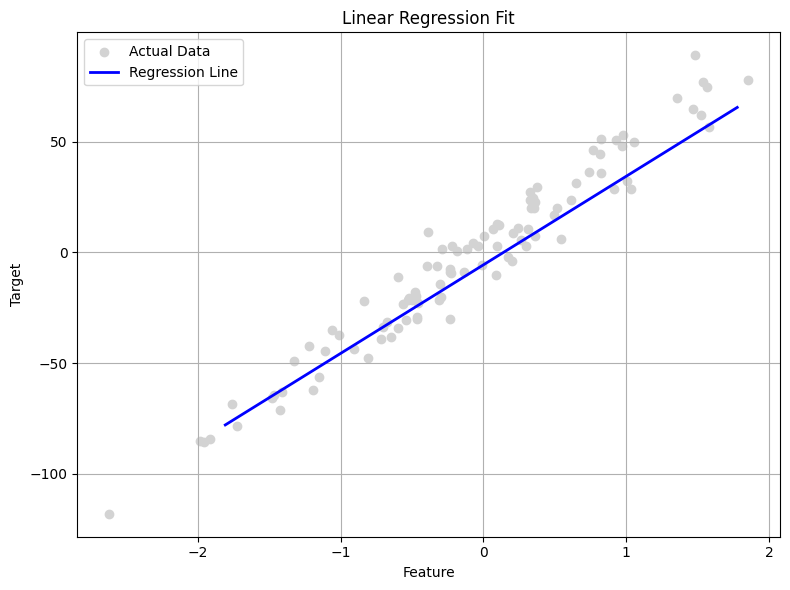

In [48]:
# Sort the data for a pretty line
sorted_idx = X_test_scaled[:, 0].argsort()
X_sorted = X_test_scaled[sorted_idx]
y_sorted = y[sorted_idx]
y_pred_sorted = y_pred_custom[sorted_idx]  # assuming you have model.predict(X) stored in y_pred

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='lightgray', label='Actual Data')
plt.plot(X_sorted, y_pred_sorted, color='blue', linewidth=2, label='Regression Line')

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

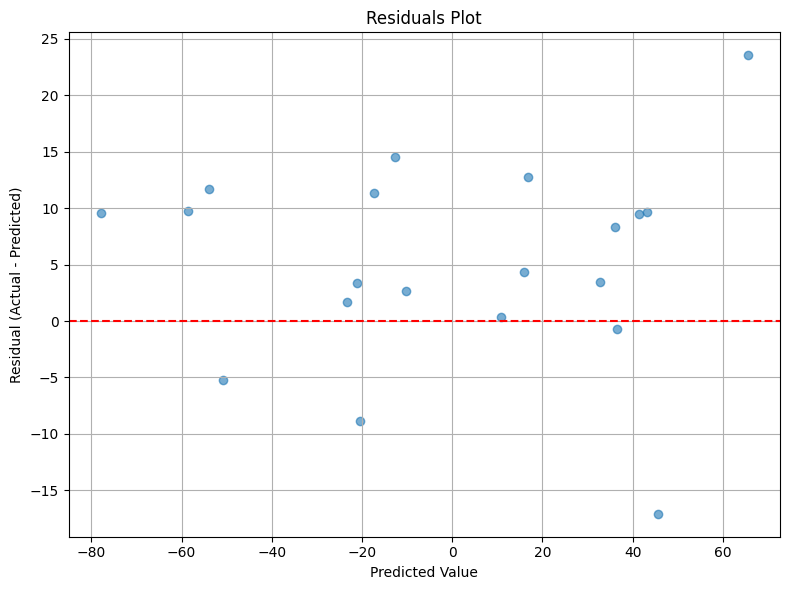

In [51]:
# Compute residuals
residuals = y_test - y_pred_custom  # or y_test - y_pred_test if you're using a test split

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_custom, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Value")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

After training the model, we evaluated its performance using:

- R² Score: Measures how well predictions match actual values; an R² of 0.9+ indicates a strong linear fit.

- Residual Plot: Shows the distribution of errors. In our case, the residuals are evenly scattered around zero, suggesting no major systematic bias.

- Prediction Plot: The predicted regression line overlays neatly on top of the true data trend.

From the scores of the linear regressor implemented here and the scikit-learn version, the models have very similar accuracy! Since the data is not representative of a real scenario, no further analysis can be done with respect to the meaning of a linear relation, but if applied to linear datasets, this algorithm can help determine important features of the data in the context of its analysis.